In [16]:
# 1 INSTALACIÓN DE DEPENDENCIAS
!pip install trimesh numpy matplotlib Pillow
!pip install trimesh[easy] vedo open3d

In [17]:
import numpy as np
import trimesh
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

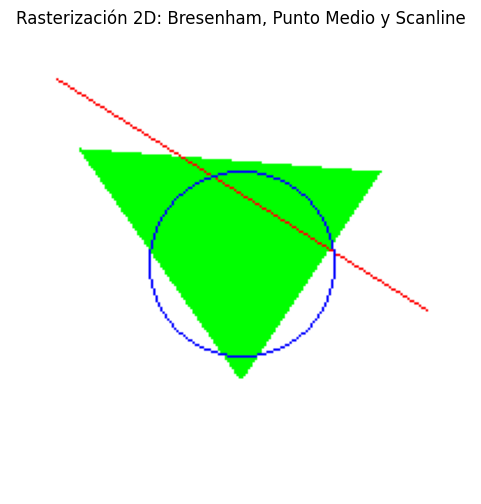

In [18]:
# 2. PREPARAR EL ENTORNO DE DIBUJO
width, height = 200, 200
image = Image.new('RGB', (width, height), 'white')
pixels = image.load()

# --- ALGORITMOS DE RASTERIZACIÓN ---

# 3. LÍNEA: Algoritmo de Bresenham
def bresenham(x0, y0, x1, y1, color=(255, 0, 0)):
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy

    while True:
        if 0 <= x0 < width and 0 <= y0 < height:
            pixels[x0, y0] = color
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x0 += sx
        if e2 < dx:
            err += dx
            y0 += sy

# 4. CÍRCULO: Algoritmo de Punto Medio
def midpoint_circle(x0, y0, radius, color=(0, 0, 255)):
    x = radius
    y = 0
    p = 1 - radius

    while x >= y:
        # Dibujar los 8 octantes simétricos
        for dx, dy in [(x, y), (y, x), (-x, y), (-y, x), (-x, -y), (-y, -x), (x, -y), (y, -x)]:
            if 0 <= x0 + dx < width and 0 <= y0 + dy < height:
                pixels[x0 + dx, y0 + dy] = color
        y += 1
        if p <= 0:
            p = p + 2 * y + 1
        else:
            x -= 1
            p = p + 2 * y - 2 * x + 1

# 5. TRIÁNGULO: Rasterización por Scanline (Relleno)
def fill_triangle(p1, p2, p3, color=(0, 255, 0)):
    # Ordenar puntos por coordenada Y
    pts = sorted([p1, p2, p3], key=lambda p: p[1])
    (x1, y1), (x2, y2), (x3, y3) = pts

    def interpolate(y_start, y_end, x_start, x_end):
        if y_end - y_start == 0: return []
        return [int(x_start + (x_end - x_start) * (y - y_start) / (y_end - y_start))
                for y in range(y_start, y_end)]

    # Interpolar coordenadas X para los tres lados
    x12 = interpolate(y1, y2, x1, x2)
    x23 = interpolate(y2, y3, x2, x3)
    x13 = interpolate(y1, y3, x1, x3)

    # El lado largo es x13, el lado compuesto es x12 + x23
    x_side_split = x12 + x23

    # Dibujar líneas horizontales entre los bordes
    for i, y in enumerate(range(y1, min(y1 + len(x13), y1 + len(x_side_split)))):
        xl = x13[i]
        xr = x_side_split[i]
        for x in range(min(xl, xr), max(xl, xr) + 1):
            if 0 <= x < width and 0 <= y < height:
                pixels[x, y] = color

# --- EJECUCIÓN DE PRUEBAS ---

# Dibujar elementos
fill_triangle((30, 50), (100, 150), (160, 60)) # Triángulo verde
bresenham(20, 20, 180, 120)                    # Línea roja
midpoint_circle(100, 100, 40)                  # Círculo azul

# 6. MOSTRAR RESULTADO
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Rasterización 2D: Bresenham, Punto Medio y Scanline")
plt.axis('off')
plt.show()

Renderizando frames con tus algoritmos...
✅ GIF generado con éxito: 'taller_rasterizacion_3d.gif'


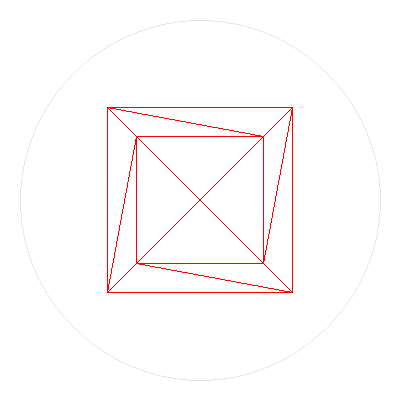

In [19]:
# --- CONFIGURACIÓN DEL LIENZO ---
WIDTH, HEIGHT = 400, 400

# --- TUS FUNCIONES DEL TALLER (Rasterización) ---

def bresenham(pixels, x0, y0, x1, y1, color):
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy
    while True:
        if 0 <= x0 < WIDTH and 0 <= y0 < HEIGHT:
            pixels[x0, y0] = color
        if x0 == x1 and y0 == y1: break
        e2 = 2 * err
        if e2 > -dy: err -= dy; x0 += sx
        if e2 < dx: err += dx; y0 += sy

def midpoint_circle(pixels, x0, y0, radius, color):
    x, y = radius, 0
    p = 1 - radius
    while x >= y:
        for dx, dy in [(x,y), (y,x), (-x,y), (-y,x), (-x,-y), (-y,-x), (x,-y), (y,-x)]:
            if 0 <= x0+dx < WIDTH and 0 <= y0+dy < HEIGHT:
                pixels[x0+dx, y0+dy] = color
        y += 1
        p = p + 2*y + 1 if p <= 0 else p + 2*y - 2*x + 1; x = x if p <= 0 else x - 1

# --- MOTOR 3D MANUAL ---

def project(vertex, angle):
    """ Proyecta un punto 3D a 2D con rotación en Y """
    # 1. Rotación en Y
    x, y, z = vertex
    rad = np.radians(angle)
    nx = x * np.cos(rad) + z * np.sin(rad)
    nz = -x * np.sin(rad) + z * np.cos(rad)

    # 2. Proyección de Perspectiva simple
    fov = 400
    distance = 4
    factor = fov / (nz + distance)
    px = int(nx * factor + WIDTH // 2)
    py = int(-y * factor + HEIGHT // 2)
    return px, py

# --- GENERACIÓN DEL GIF ---

# 1. Crear un cubo 3D (vuelve a tus bases de geometría)
cube = trimesh.creation.box(extents=(1.5, 1.5, 1.5))
edges = cube.edges_unique

frames = []
print("Renderizando frames con tus algoritmos...")

for angle in range(0, 360, 10):
    # Crear imagen nueva para cada frame
    img = Image.new('RGB', (WIDTH, HEIGHT), 'white')
    pxs = img.load()

    # A. Dibujamos un círculo decorativo de fondo con tu algoritmo de Punto Medio
    midpoint_circle(pxs, WIDTH//2, HEIGHT//2, 180, (230, 230, 230))

    # B. Proyectamos y dibujamos las aristas del cubo con tu algoritmo de Bresenham
    for edge in edges:
        v1_3d = cube.vertices[edge[0]]
        v2_3d = cube.vertices[edge[1]]

        p1_2d = project(v1_3d, angle)
        p2_2d = project(v2_3d, angle)

        # Invocamos tu función de línea
        bresenham(pxs, p1_2d[0], p1_2d[1], p2_2d[0], p2_2d[1], (255, 0, 0))

    frames.append(img)

# Guardar como GIF
frames[0].save('taller_rasterizacion_3d.gif', save_all=True,
               append_images=frames[1:], duration=50, loop=0)

print("✅ GIF generado con éxito: 'taller_rasterizacion_3d.gif'")

# MOSTRAR RESULTADO
from IPython.display import Image as DisplayImage
DisplayImage(open('taller_rasterizacion_3d.gif', 'rb').read())